In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [2]:
df = ev.build_results("results")

/Users/s.franke/Development/master_clean/experiments/evaluation.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.apply(calc_row, axis=1, args=(err_col, conf_col))


In [3]:
df.to_csv("results_2.csv", index=False)

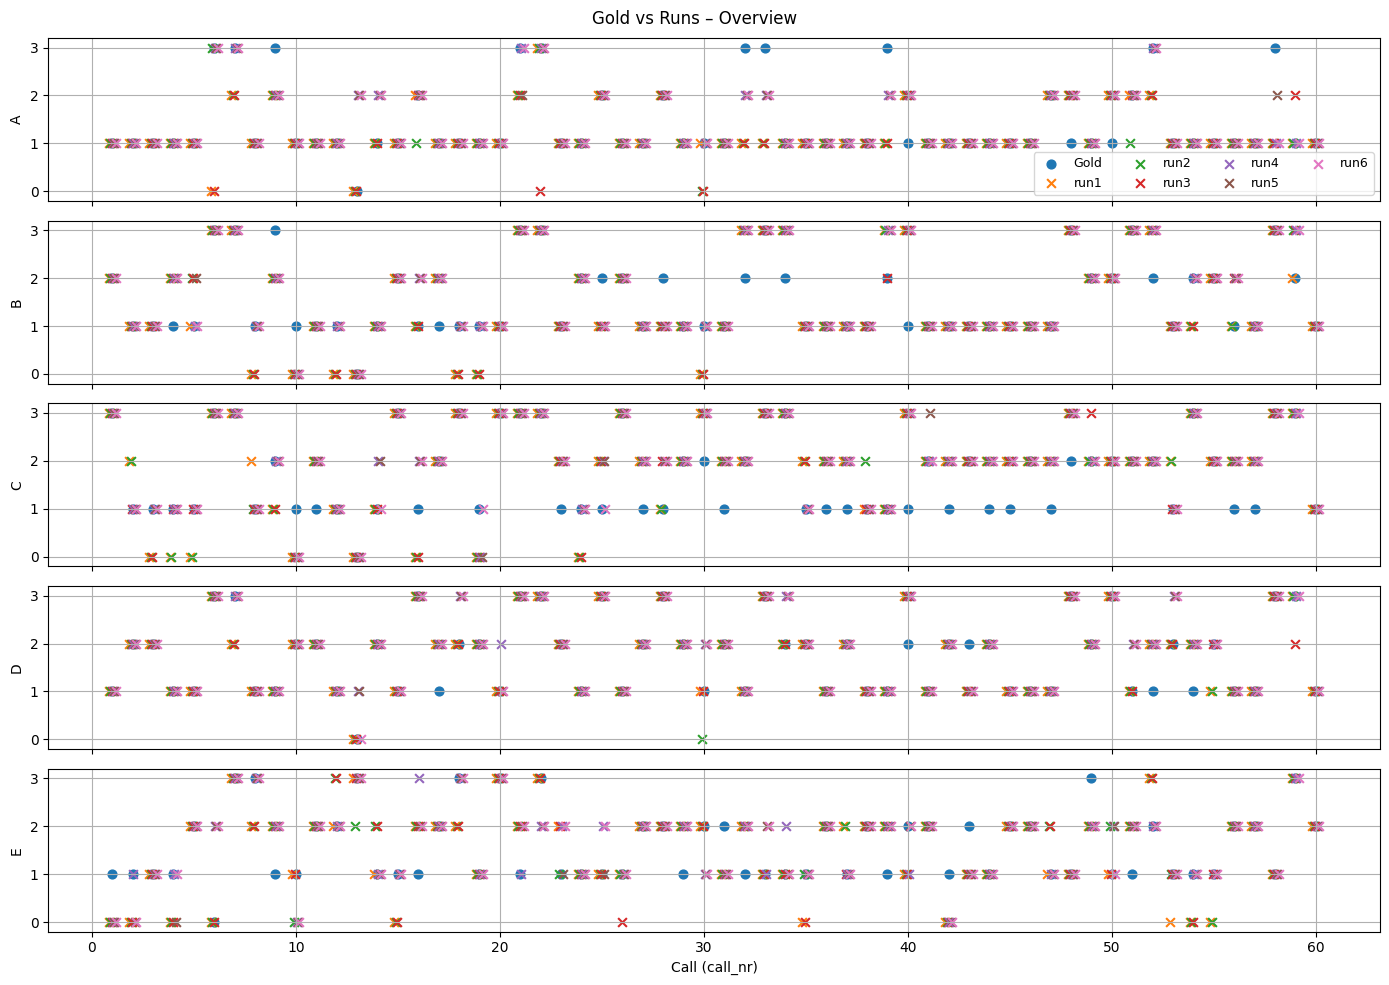

In [25]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [26]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.710000,0.300,42.60,1.238627
1,conf_error,1,B,60,0.424833,0.250,25.49,0.628669
2,conf_error,1,C,60,0.419167,0.400,25.15,0.474561
3,conf_error,1,D,60,0.377500,0.300,22.65,0.528351
4,conf_error,1,E,60,0.573000,0.500,34.38,0.751403
5,conf_error,2,A,60,0.725000,0.300,43.50,1.313197
6,conf_error,2,B,60,0.440000,0.275,26.40,0.642467
7,conf_error,2,C,60,0.425167,0.450,25.51,0.487909
8,conf_error,2,D,60,0.361500,0.270,21.69,0.499224
9,conf_error,2,E,60,0.622500,0.500,37.35,0.809299


In [27]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.710000,0.424833,0.419167,0.377500,0.573000
2,0.725000,0.440000,0.425167,0.361500,0.622500
3,0.703167,0.433333,0.462833,0.392500,0.569167
4,0.470833,0.420000,0.436667,0.306167,0.534167
5,0.466949,0.414407,0.440678,0.295763,0.498305
6,0.470000,0.418333,0.442500,0.297000,0.490000


In [28]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.800000,0.400000,0.516667,0.183333,0.566667
2,0.733333,0.433333,0.516667,0.200000,0.650000
3,0.983333,0.433333,0.466667,0.200000,0.583333
4,0.416667,0.333333,0.383333,0.216667,0.533333
5,0.423729,0.338983,0.406780,0.203390,0.491525
6,0.416667,0.333333,0.333333,0.183333,0.483333


In [29]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.500900,150.27,4.50
1,conf_error,2,300,0.514833,154.45,4.50
2,conf_error,3,300,0.512200,153.66,4.20
3,conf_error,4,300,0.433567,130.07,4.80
4,conf_error,5,295,0.423220,124.85,2.55
5,conf_error,6,300,0.423567,127.07,4.80
6,error,1,300,0.493333,148.00,9.00
7,error,2,300,0.506667,152.00,6.00
8,error,3,300,0.533333,160.00,9.00
9,error,4,300,0.376667,113.00,6.00


In [30]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,148,150.27
1,2,152,154.45
2,3,160,153.66
3,4,113,130.07
4,5,110,124.85
5,6,105,127.07


In [10]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.825112,184.0,0.661839,147.59
1,B,0.376682,84.0,0.419013,93.44
2,C,0.443946,99.0,0.423677,94.48
3,D,0.174888,39.0,0.351525,78.39
4,E,0.582960,130.0,0.575022,128.23


In [4]:
(df == 9).sum()


A                 0
A_1               0
A_1_conf          0
A_1_conf_error    0
A_1_error         1
                 ..
E_5_error         0
E_6               0
E_6_conf          0
E_6_conf_error    0
E_6_error         0
Length: 125, dtype: int64

In [13]:
import tiktoken


OUTPUT_CONTRACT_DEFAULT = """
Return ONLY valid JSON (no markdown, no commentary).

Schema:
{
  "A": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "B": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "C": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "D": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>},
  "E": {"severity": <int or null>, "confidence": <float 0..1 or null>, "findings": <list of strings>}
}
""".strip()

guidelines =Path("guidelines/guidelines.md").read_text(encoding="utf-8")

text = guidelines + "\n\n" + OUTPUT_CONTRACT_DEFAULT


## Token zählen: 


encoding = tiktoken.get_encoding("o200k_base")

tokens = encoding.encode(text)

print("GPT 5.2:" , len(tokens))

GPT 5.2: 922


In [14]:
import anthropic
import pandas as pd
import requests
from dotenv import load_dotenv
from anthropic import Anthropic
import os

load_dotenv()
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
client = anthropic.Anthropic()

response = client.messages.count_tokens(
    model="claude-opus-4-6",
    messages=[{"role": "user", "content": text}],
)

print(response.json())

{"input_tokens":1159}


/var/folders/9k/bqn5d5t90kl0x7z66fx4d0cw0000gn/T/ipykernel_22980/1825925790.py:17: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(response.json())


In [ ]:
df